### Traditional Pipeline: Colour Hist + HoG + Random Forest

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/COMP9517/Data/train_select.zip /content/
!cp /content/drive/MyDrive/COMP9517/Data/test_select.zip /content/

!mkdir -p Data
!unzip -q /content/train_select.zip -d Data/train_select
!unzip -q /content/test_select.zip -d Data/test_select

In [3]:
!mv Data/train_select/train_select/* Data/train_select/
!rmdir Data/train_select/train_select

In [4]:
!mv Data/test_select/test_select/* Data/test_select/
!rmdir Data/test_select/test_select

In [5]:
from pathlib import Path
from collections import defaultdict
import random
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
import joblib

In [6]:
train_dir = Path("Data/train_select")
test_dir = Path("Data/test_select")

seed = 20269517
rng = random.Random(seed)

def get_paths_labels(root_dir):
  paths, labels = [], []
  for folder in sorted(root_dir.iterdir()):
    if folder.is_dir():
      for img_path in folder.glob("*.jpg"):
        paths.append(img_path)
        labels.append(folder.name)
  return paths, labels

full_paths, full_labels = get_paths_labels(train_dir)
test_paths, test_labels = get_paths_labels(test_dir)

# Split full_paths into 40 train + 10 val
paths_by_species = defaultdict(list)
for path, label in zip(full_paths, full_labels):
  paths_by_species[label].append(path)

train_paths, train_labels = [], []
val_paths, val_labels = [], []

for species, paths in paths_by_species.items():
    paths = sorted(paths)
    rng.shuffle(paths)
    train_paths.extend(paths[:40])
    train_labels.extend([species] * 40)
    val_paths.extend(paths[40:50])
    val_labels.extend([species] * 10)

print(f"Train: {len(train_paths)} images")
print(f"Val: {len(val_paths)} images")
print(f"Test: {len(test_paths)} images")

Train: 40000 images
Val: 10000 images
Test: 10000 images


In [7]:
DRIVE_DATA_DIR = "/content/drive/MyDrive/COMP9517/Data"

## Data Extraction

In [ ]:
IMG_SIZE = (128, 128)

def extract_colour_histogram_HSV(image, bins):
  hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
  hist = cv2.calcHist([hsv],
                      [0, 1, 2],
                      None,
                      bins,
                      [0, 180, 0, 256, 0, 256])
  cv2.normalize(hist, hist)
  return hist.flatten()

def extract_colour_histogram_LAB(image, bins):
  lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
  hist = cv2.calcHist([lab],
                      [0, 1, 2],
                      None,
                      bins,
                      [0, 256, 0, 256, 0, 256])
  cv2.normalize(hist, hist)
  return hist.flatten()

def extract_hog_features(image, orientation, cell_pixels, block_cells):
  grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  features = hog(grey,
                 orientations=orientation,
                 pixels_per_cell=cell_pixels,
                 cells_per_block=block_cells)
  return features

def extract_features(
    img,
    colour_rep, hist_bins,
    hog_orientation, hog_cell_pixels, hog_block_cells
  ):

  if colour_rep == 'hsv':
    colour_feat = extract_colour_histogram_HSV(img, hist_bins)
  elif colour_rep == 'lab':
    colour_feat = extract_colour_histogram_LAB(img, hist_bins)

  hog_feat = extract_hog_features(img, hog_orientation, hog_cell_pixels, hog_block_cells)

  return np.concatenate([colour_feat, hog_feat])

def build_baseline_features(paths):
  features = []
  for i, p in enumerate(paths):
    img = cv2.imread(str(p))
    img = cv2.resize(img, IMG_SIZE)
    features.append(extract_features(img, 'hsv', (8, 8, 8), 9, (8, 8), (2, 2)))
  return np.array(features)

# Fewer cell pixels means more discriminative features
def build_hog_diff_features(paths):
  features = []
  for i, p in enumerate(paths):
    img = cv2.imread(str(p))
    img = cv2.resize(img, IMG_SIZE)
    features.append(extract_features(img, 'hsv', (8, 8, 8), 9, (6, 6), (2, 2)))
  return np.array(features)

# Using L*A*B which is more uniform - may capture subtle details
def build_lab_features(paths):
  features = []
  for i, p in enumerate(paths):
    img = cv2.imread(str(p))
    img = cv2.resize(img, IMG_SIZE)
    features.append(extract_features(img, 'lab', (8, 8, 8), 9, (8, 8), (2, 2)))
  return np.array(features)


print("Baseline model:")
X_train_base = build_baseline_features(train_paths)
np.save(f"{DRIVE_DATA_DIR}/X_train_base.npy", X_train_base)
print(f"  X_train shape: {X_train_base.shape}")
del X_train_base

X_val_base = build_baseline_features(val_paths)
np.save(f"{DRIVE_DATA_DIR}/X_val_base.npy", X_val_base)
print(f"  X_val shape: {X_val_base.shape}")
del X_val_base

X_test_base = build_baseline_features(test_paths)
np.save(f"{DRIVE_DATA_DIR}/X_test_base.npy", X_test_base)
print(f"  X_test shape: {X_test_base.shape}")
del X_test_base


print("\n HOG diff model - fewer cell pixels:")
X_train_hog_diff = build_hog_diff_features(train_paths)
np.save(f"{DRIVE_DATA_DIR}/X_train_hog_diff.npy", X_train_hog_diff)
print(f"  X_train shape: {X_train_hog_diff.shape}")
del X_train_hog_diff

X_val_hog_diff = build_hog_diff_features(val_paths)
np.save(f"{DRIVE_DATA_DIR}/X_val_hog_diff.npy", X_val_hog_diff)
print(f"  X_val shape: {X_val_hog_diff.shape}")
del X_val_hog_diff

X_test_hog_diff = build_hog_diff_features(test_paths)
np.save(f"{DRIVE_DATA_DIR}/X_test_hog_diff.npy", X_test_hog_diff)
print(f"  X_test shape: {X_test_hog_diff.shape}")
del X_test_hog_diff


print("\n Using L*A*B instead of HSV:")
X_train_lab = build_lab_features(train_paths)
np.save(f"{DRIVE_DATA_DIR}/X_train_lab.npy", X_train_lab)
print(f"  X_train shape: {X_train_lab.shape}")
del X_train_lab

X_val_lab = build_lab_features(val_paths)
np.save(f"{DRIVE_DATA_DIR}/X_val_lab.npy", X_val_lab)
print(f"  X_val shape: {X_val_lab.shape}")
del X_val_lab

X_test_lab = build_lab_features(test_paths)
np.save(f"{DRIVE_DATA_DIR}/X_test_lab.npy", X_test_lab)
print(f"  X_test shape: {X_test_lab.shape}")
del X_test_lab


Baseline model:
  X_train shape: (40000, 8612)
  X_val shape: (10000, 8612)
  X_test shape: (10000, 8612)

 HOG diff model - fewer cell pixels:
  X_train shape: (40000, 14912)
  X_val shape: (10000, 14912)
  X_test shape: (10000, 14912)

 Using L*A*B instead of HSV:
  X_train shape: (40000, 8612)
  X_val shape: (10000, 8612)
  X_test shape: (10000, 8612)


In [ ]:
del train_paths, val_paths, test_paths

## Baseline Model

In [ ]:
base_image_rf_classifier = RandomForestClassifier(n_estimators=150,
                                                  max_depth=20,
                                                  n_jobs=-1,
                                                  random_state=seed,
                                                  warm_start=True,
                                                  verbose=2)
X_train_base = np.load(f"{DRIVE_DATA_DIR}/X_train_base.npy")
base_fit = base_image_rf_classifier.fit(X_train_base, train_labels)
del X_train_base

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 150
building tree 2 of 150
building tree 3 of 150
building tree 4 of 150
building tree 5 of 150
building tree 6 of 150
building tree 7 of 150
building tree 8 of 150
building tree 9 of 150
building tree 10 of 150
building tree 11 of 150
building tree 12 of 150
building tree 13 of 150
building tree 14 of 150
building tree 15 of 150
building tree 16 of 150
building tree 17 of 150
building tree 18 of 150
building tree 19 of 150
building tree 20 of 150
building tree 21 of 150
building tree 22 of 150
building tree 23 of 150
building tree 24 of 150
building tree 25 of 150
building tree 26 of 150
building tree 27 of 150
building tree 28 of 150
building tree 29 of 150
building tree 30 of 150
building tree 31 of 150
building tree 32 of 150
building tree 33 of 150
building tree 34 of 150
building tree 35 of 150
building tree 36 of 150
building tree 37 of 150
building tree 38 of 150
building tree 39 of 150


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 49.2min


building tree 40 of 150
building tree 41 of 150
building tree 42 of 150
building tree 43 of 150
building tree 44 of 150
building tree 45 of 150
building tree 46 of 150
building tree 47 of 150
building tree 48 of 150
building tree 49 of 150
building tree 50 of 150
building tree 51 of 150
building tree 52 of 150
building tree 53 of 150
building tree 54 of 150
building tree 55 of 150
building tree 56 of 150
building tree 57 of 150
building tree 58 of 150
building tree 59 of 150
building tree 60 of 150
building tree 61 of 150
building tree 62 of 150
building tree 63 of 150
building tree 64 of 150
building tree 65 of 150
building tree 66 of 150
building tree 67 of 150
building tree 68 of 150
building tree 69 of 150
building tree 70 of 150
building tree 71 of 150
building tree 72 of 150
building tree 73 of 150
building tree 74 of 150
building tree 75 of 150
building tree 76 of 150
building tree 77 of 150
building tree 78 of 150
building tree 79 of 150
building tree 80 of 150
building tree 81

[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed: 191.8min finished


In [ ]:
# Save the trained classifier to disk
joblib.dump(base_image_rf_classifier, f"{DRIVE_DATA_DIR}/base_rf_150_estimators.joblib")

del base_image_rf_classifier
del base_fit

## HOG Diff Model

In [ ]:
hog_image_rf_classifier = RandomForestClassifier(n_estimators=150,
                                                 max_depth=20,
                                                 n_jobs=-1,
                                                 random_state=seed,
                                                 warm_start=True,
                                                 verbose=2)

X_train_hog_diff = np.load(f"{DRIVE_DATA_DIR}/X_train_hog_diff.npy")
hog_diff_fit = hog_image_rf_classifier.fit(X_train_hog_diff, train_labels)
del X_train_hog_diff

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 150
building tree 2 of 150
building tree 3 of 150
building tree 4 of 150
building tree 5 of 150
building tree 6 of 150
building tree 7 of 150
building tree 8 of 150
building tree 9 of 150
building tree 10 of 150
building tree 11 of 150
building tree 12 of 150
building tree 13 of 150
building tree 14 of 150
building tree 15 of 150
building tree 16 of 150
building tree 17 of 150
building tree 18 of 150
building tree 19 of 150
building tree 20 of 150
building tree 21 of 150
building tree 22 of 150
building tree 23 of 150
building tree 24 of 150
building tree 25 of 150
building tree 26 of 150
building tree 27 of 150
building tree 28 of 150
building tree 29 of 150
building tree 30 of 150
building tree 31 of 150
building tree 32 of 150
building tree 33 of 150
building tree 34 of 150
building tree 35 of 150
building tree 36 of 150
building tree 37 of 150
building tree 38 of 150
building tree 39 of 150


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 62.6min


building tree 40 of 150
building tree 41 of 150
building tree 42 of 150
building tree 43 of 150
building tree 44 of 150
building tree 45 of 150
building tree 46 of 150
building tree 47 of 150
building tree 48 of 150
building tree 49 of 150
building tree 50 of 150
building tree 51 of 150
building tree 52 of 150
building tree 53 of 150
building tree 54 of 150
building tree 55 of 150
building tree 56 of 150
building tree 57 of 150
building tree 58 of 150
building tree 59 of 150
building tree 60 of 150
building tree 61 of 150
building tree 62 of 150
building tree 63 of 150
building tree 64 of 150
building tree 65 of 150
building tree 66 of 150
building tree 67 of 150
building tree 68 of 150
building tree 69 of 150
building tree 70 of 150
building tree 71 of 150
building tree 72 of 150
building tree 73 of 150
building tree 74 of 150
building tree 75 of 150
building tree 76 of 150
building tree 77 of 150
building tree 78 of 150
building tree 79 of 150
building tree 80 of 150
building tree 81

[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed: 246.7min finished


In [ ]:
# Save the trained classifier to disk
joblib.dump(hog_image_rf_classifier, f"{DRIVE_DATA_DIR}/hog_rf_150_estimators.joblib")

del hog_image_rf_classifier
del hog_diff_fit

## L\*a\*b Colour Space Model

In [ ]:
lab_image_rf_classifier = RandomForestClassifier(n_estimators=150,
                                                 max_depth=20,
                                                 n_jobs=-1,
                                                 random_state=seed,
                                                 warm_start=True,
                                                 verbose=2)

X_train_lab = np.load(f"{DRIVE_DATA_DIR}/X_train_lab.npy")
lab_fit = lab_image_rf_classifier.fit(X_train_lab, train_labels)
del X_train_lab

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 150
building tree 2 of 150
building tree 3 of 150
building tree 4 of 150
building tree 5 of 150
building tree 6 of 150
building tree 7 of 150
building tree 8 of 150
building tree 9 of 150
building tree 10 of 150
building tree 11 of 150
building tree 12 of 150
building tree 13 of 150
building tree 14 of 150
building tree 15 of 150
building tree 16 of 150
building tree 17 of 150
building tree 18 of 150
building tree 19 of 150
building tree 20 of 150
building tree 21 of 150
building tree 22 of 150
building tree 23 of 150
building tree 24 of 150
building tree 25 of 150
building tree 26 of 150
building tree 27 of 150
building tree 28 of 150
building tree 29 of 150
building tree 30 of 150
building tree 31 of 150
building tree 32 of 150
building tree 33 of 150
building tree 34 of 150
building tree 35 of 150
building tree 36 of 150
building tree 37 of 150
building tree 38 of 150
building tree 39 of 150


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 47.7min


building tree 40 of 150
building tree 41 of 150
building tree 42 of 150
building tree 43 of 150
building tree 44 of 150
building tree 45 of 150
building tree 46 of 150
building tree 47 of 150
building tree 48 of 150
building tree 49 of 150
building tree 50 of 150
building tree 51 of 150
building tree 52 of 150
building tree 53 of 150
building tree 54 of 150
building tree 55 of 150
building tree 56 of 150
building tree 57 of 150
building tree 58 of 150
building tree 59 of 150
building tree 60 of 150
building tree 61 of 150
building tree 62 of 150
building tree 63 of 150
building tree 64 of 150
building tree 65 of 150
building tree 66 of 150
building tree 67 of 150
building tree 68 of 150
building tree 69 of 150
building tree 70 of 150
building tree 71 of 150
building tree 72 of 150
building tree 73 of 150
building tree 74 of 150
building tree 75 of 150
building tree 76 of 150
building tree 77 of 150
building tree 78 of 150
building tree 79 of 150
building tree 80 of 150
building tree 81

[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed: 185.1min finished


In [ ]:
# Save the trained classifier to disk
joblib.dump(lab_image_rf_classifier, f"{DRIVE_DATA_DIR}/lab_rf_150_estimators.joblib")

del lab_image_rf_classifier
del lab_fit

## Comparison

In [ ]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_model(model, X_val, val_labels, name):
  y_pred = model.predict(X_val)

  return {
    "Model": name,
    "(Balanced) Accuracy": balanced_accuracy_score(val_labels, y_pred),
    "Precision (macro)": precision_score(val_labels, y_pred, average='macro'),
    "Recall (macro)": recall_score(val_labels, y_pred, average='macro'),
    "F1 (macro)": f1_score(val_labels, y_pred, average='macro')
  }

def top_1_and_5_accuracy(model, X_val, val_labels, name):
  y_pred = model.predict_proba(X_val)
  y_true = np.asarray(val_labels)
  classes = model.classes_

  top_1_idx = np.argsort(y_pred, axis=1)[:, -1:]
  top_1_preds = classes[top_1_idx]
  correct = sum(y_true[i] in top_1_preds[i] for i in range(len(y_true)))
  top_1 = correct / len(y_true)

  top_5_idx = np.argsort(y_pred, axis=1)[:, -5:]
  top_5_preds = classes[top_5_idx]
  correct = sum(y_true[i] in top_5_preds[i] for i in range(len(y_true)))
  top_5 = correct / len(y_true)

  return {
      "Model": name,
      "Top 1 Accuracy": top_1,
      "Top 5 Accuracy": top_5
  }

In [ ]:
results = []
topk_accuracies = []

# Baseline
X_val_base = np.load(f"{DRIVE_DATA_DIR}/X_val_base.npy")
base_fit = joblib.load(f"{DRIVE_DATA_DIR}/base_rf_150_estimators.joblib")
results.append(evaluate_model(base_fit, X_val_base, val_labels, "Baseline (HSV, HOG 8x8)"))
topk_accuracies.append(top_1_and_5_accuracy(base_fit, X_val_base, val_labels, "Baseline (HSV, HOG 8x8)"))
del X_val_base
del base_fit

# HoG diff
X_val_hog_diff = np.load(f"{DRIVE_DATA_DIR}/X_val_hog_diff.npy")
hog_diff_fit = joblib.load(f"{DRIVE_DATA_DIR}/hog_rf_150_estimators.joblib")
results.append(evaluate_model(hog_diff_fit, X_val_hog_diff, val_labels, "HOG diff (cells 6x6)"))
topk_accuracies.append(top_1_and_5_accuracy(hog_diff_fit, X_val_hog_diff, val_labels, "HOG diff (cells 6x6)"))
del X_val_hog_diff
del hog_diff_fit

# LAB
X_val_lab = np.load(f"{DRIVE_DATA_DIR}/X_val_lab.npy")
lab_fit = joblib.load(f"{DRIVE_DATA_DIR}/lab_rf_150_estimators.joblib")
results.append(evaluate_model(lab_fit, X_val_lab, val_labels, "LAB colour space"))
topk_accuracies.append(top_1_and_5_accuracy(lab_fit, X_val_lab, val_labels, "LAB colour space"))
del X_val_lab
del lab_fit

main_results_df = pd.DataFrame(results)
topk_df = pd.DataFrame(topk_accuracies)

comparison_df = main_results_df.merge(topk_df, on="Model")
print(comparison_df.to_string(index=False))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.1s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    5.0s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.5s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    4.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.8s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    4.9s finished
/usr/local/lib/python3.12/dist-packages/sklearn/me

                  Model  (Balanced) Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Top 1 Accuracy  Top 5 Accuracy
Baseline (HSV, HOG 8x8)               0.0319           0.019108          0.0319    0.018629          0.0319          0.0999
   HOG diff (cells 6x6)               0.0281           0.012749          0.0281    0.015048          0.0281          0.0880
       LAB colour space               0.0279           0.015747          0.0279    0.015849          0.0279          0.0928


## Best Model Trained Longer

In [ ]:
X_train_base = np.load(f"{DRIVE_DATA_DIR}/X_train_base.npy")
base_fit = joblib.load(f"{DRIVE_DATA_DIR}/base_rf_150_estimators.joblib")
base_fit.set_params(n_estimators=200)
longer_train_a = base_fit.fit(X_train_base, train_labels)
joblib.dump(longer_train_a, f"{DRIVE_DATA_DIR}/base_rf_200_estimators.joblib")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 49.2min


building tree 40 of 50
building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 64.9min finished


['/content/drive/MyDrive/COMP9517/Data/base_rf_200_estimators.joblib']

In [ ]:
X_train_base = np.load(f"{DRIVE_DATA_DIR}/X_train_base.npy")
base_fit.set_params(n_estimators=300)
longer_train_b = base_fit.fit(X_train_base, train_labels)
joblib.dump(longer_train_b, f"{DRIVE_DATA_DIR}/base_rf_300_estimators.joblib")
del X_train_base

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 49.0min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 129.4min finished


In [ ]:
X_train_base = np.load(f"{DRIVE_DATA_DIR}/X_train_base.npy")
base_fit = joblib.load(f"{DRIVE_DATA_DIR}/base_rf_300_estimators.joblib")
base_fit.set_params(n_estimators=400)
longer_train_c = base_fit.fit(X_train_base, train_labels)
joblib.dump(longer_train_c, f"{DRIVE_DATA_DIR}/base_rf_400_estimators.joblib")
del X_train_base

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 48.2min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 126.5min finished


In [ ]:
del longer_train_a, longer_train_b, longer_train_c, base_fit

In [ ]:
import gc
X_val_base = np.load(f"{DRIVE_DATA_DIR}/X_val_base.npy")
results_2 = []
topk_accuracies_2 = []

model_a = joblib.load(f"{DRIVE_DATA_DIR}/base_rf_200_estimators.joblib")
results_2.append(evaluate_model(model_a, X_val_base, val_labels, "Baseline trained longer (200 estimators)"))
topk_accuracies_2.append(top_1_and_5_accuracy(model_a, X_val_base, val_labels, "Baseline trained longer (200 estimators)"))
del model_a
gc.collect()

model_b = joblib.load(f"{DRIVE_DATA_DIR}/base_rf_300_estimators.joblib")
results_2.append(evaluate_model(model_b, X_val_base, val_labels, "Baseline trained longer (300 estimators)"))
topk_accuracies_2.append(top_1_and_5_accuracy(model_b, X_val_base, val_labels, "Baseline trained longer (300 estimators)"))
del model_b
gc.collect()

np.save(f"{DRIVE_DATA_DIR}/results_2.npy", results_2)
np.save(f"{DRIVE_DATA_DIR}/topk_accuracies_2.npy", topk_accuracies_2)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.3s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    5.6s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    7.3s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.4s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    5.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    6.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.7

In [ ]:
X_val_base = np.load(f"{DRIVE_DATA_DIR}/X_val_base.npy")
results_2 = np.load(f"{DRIVE_DATA_DIR}/results_2.npy", allow_pickle=True).tolist()
topk_accuracies_2 = np.load(f"{DRIVE_DATA_DIR}/topk_accuracies_2.npy", allow_pickle=True).tolist()
model_c = joblib.load(f"{DRIVE_DATA_DIR}/base_rf_400_estimators.joblib")

results_2.append(evaluate_model(model_c, X_val_base, val_labels, "Baseline trained longer (400 estimators)"))
topk_accuracies_2.append(top_1_and_5_accuracy(model_c, X_val_base, val_labels, "Baseline trained longer (400 estimators)"))
del X_val_base

main_results_longer_df = pd.DataFrame(results_2)
topk_longer_df = pd.DataFrame(topk_accuracies_2)

comparison_longer_df = main_results_longer_df.merge(topk_longer_df, on="Model")
comparison_longer_df = comparison_longer_df.drop_duplicates()
print(comparison_longer_df.to_string(index=False))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    4.6s
[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:   12.1s
[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:   13.2s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.1s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    4.7s
[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:   11.6s
[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:   13.1s finished


                                   Model  (Balanced) Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Top 1 Accuracy  Top 5 Accuracy
Baseline trained longer (200 estimators)               0.0340           0.020717          0.0340    0.020112          0.0340          0.1014
Baseline trained longer (300 estimators)               0.0358           0.020426          0.0358    0.020850          0.0358          0.1087
Baseline trained longer (400 estimators)               0.0395           0.024314          0.0395    0.023094          0.0395          0.1131


## Test and Evaluation

In [ ]:
X_test_base = np.load(f"{DRIVE_DATA_DIR}/X_test_base.npy")
final_test = []
topk_accuracies_final = []
final_test.append(evaluate_model(model_c, X_test_base, test_labels, "Test with Baseline 400 estimator Model"))
topk_accuracies_final.append(top_1_and_5_accuracy(model_c, X_test_base, test_labels, "Test with Baseline 400 estimator Model"))

main_results_test_df = pd.DataFrame(final_test)
topk_test_df = pd.DataFrame(topk_accuracies_final)

results_test_df = main_results_test_df.merge(topk_test_df, on="Model")
print(results_test_df.to_string(index=False))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    4.8s
[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:   11.8s
[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:   13.0s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.1s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    4.5s
[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:   11.7s
[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:   12.8s finished


                                 Model  (Balanced) Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Top 1 Accuracy  Top 5 Accuracy
Test with Baseline 400 estimator Model               0.0368           0.024126          0.0368    0.022273          0.0368          0.1085


In [ ]:
X_test_base = np.load(f"{DRIVE_DATA_DIR}/X_test_base.npy")
model_b = joblib.load(f"{DRIVE_DATA_DIR}/base_rf_300_estimators.joblib")
final_test = []
topk_accuracies_final = []
final_test.append(evaluate_model(model_b, X_test_base, test_labels, "Test with Baseline 300 estimator Model"))
topk_accuracies_final.append(top_1_and_5_accuracy(model_b, X_test_base, test_labels, "Test with Baseline 300 estimator Model"))

main_results_test_df = pd.DataFrame(final_test)
topk_test_df = pd.DataFrame(topk_accuracies_final)

results_test_df = main_results_test_df.merge(topk_test_df, on="Model")
print(results_test_df.to_string(index=False))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.1s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    4.5s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    9.6s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.5s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    5.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    9.0s finished


                                 Model  (Balanced) Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Top 1 Accuracy  Top 5 Accuracy
Test with Baseline 300 estimator Model               0.0364           0.023936          0.0364    0.022639          0.0364          0.1061


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    3.9s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:   12.3s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:   18.5s finished


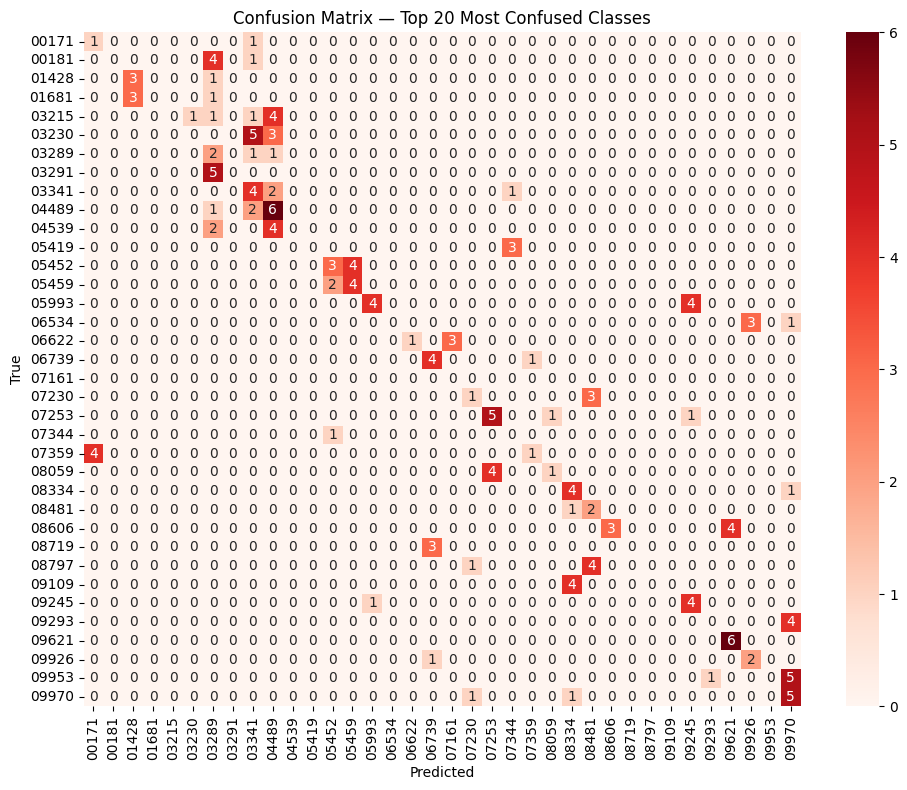

00171: 00171_Animalia_Arthropoda_Hexanauplia_Sessilia_Balanidae_Balanus_glandula
00181: 00181_Animalia_Arthropoda_Insecta_Blattodea_Blattidae_Periplaneta_fuliginosa
01428: 01428_Animalia_Arthropoda_Insecta_Lepidoptera_Limacodidae_Apoda_y-inversum
01681: 01681_Animalia_Arthropoda_Insecta_Lepidoptera_Noctuidae_Peridroma_saucia
03215: 03215_Animalia_Chordata_Aves_Anseriformes_Anatidae_Aythya_affinis
03230: 03230_Animalia_Chordata_Aves_Anseriformes_Anatidae_Bucephala_albeola
03289: 03289_Animalia_Chordata_Aves_Caprimulgiformes_Apodidae_Chaetura_vauxi
03291: 03291_Animalia_Chordata_Aves_Caprimulgiformes_Caprimulgidae_Chordeiles_acutipennis
03341: 03341_Animalia_Chordata_Aves_Charadriiformes_Alcidae_Cerorhinca_monocerata
04489: 04489_Animalia_Chordata_Aves_Procellariiformes_Procellariidae_Ardenna_creatopus
04539: 04539_Animalia_Chordata_Aves_Sphenisciformes_Spheniscidae_Spheniscus_magellanicus
05419: 05419_Fungi_Ascomycota_Lecanoromycetes_Lecanorales_Parmeliaceae_Usnea_longissima
05452: 0545

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Extract just the numeric code prefix from each class label
def get_code(label):
    return label.split("_")[0]

unique_labels = sorted(set(test_labels))

y_pred = model_b.predict(X_test_base)
cm = confusion_matrix(test_labels, y_pred, labels=unique_labels)
cm_df = pd.DataFrame(cm, index=unique_labels, columns=unique_labels)

cm_list = cm_df.reset_index().melt(id_vars="index", var_name="Predicted", value_name="Count")
cm_list = cm_list.rename(columns={"index": "True"})
cm_list = cm_list[cm_list['True'] != cm_list['Predicted']]

# Get the top 20 most confused pairs
top20_confused = cm_list.sort_values("Count", ascending=False).head(20)
confused_classes = pd.unique(top20_confused[["True", "Predicted"]].values.ravel())

confused_classes_sorted = sorted(confused_classes, key=get_code)

cm_subset_df = cm_df.loc[confused_classes_sorted, confused_classes_sorted]
short_labels_sorted = [get_code(c) for c in confused_classes_sorted]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_subset_df, annot=True, fmt="d", cmap="Reds",
            xticklabels=short_labels_sorted, yticklabels=short_labels_sorted)
plt.title("Confusion Matrix — Top 20 Most Confused Classes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

code_to_name = {get_code(c): c for c in confused_classes}

# Print the full list, sorted by code for easy lookup
for code, full_name in sorted(code_to_name.items()):
    print(f"{code}: {full_name}")

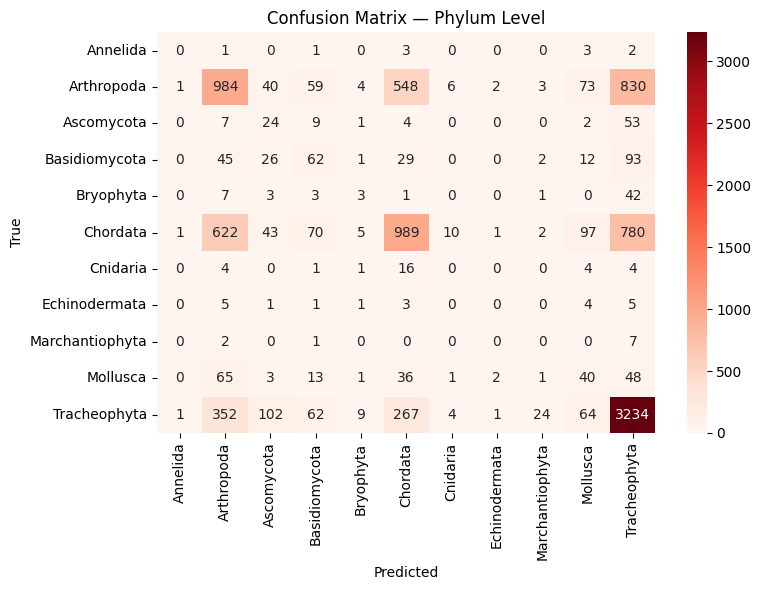

Tracheophyta       4120
Chordata           2620
Arthropoda         2550
Basidiomycota       270
Mollusca            210
Ascomycota          100
Bryophyta            60
Cnidaria             30
Echinodermata        20
Annelida             10
Marchantiophyta      10


In [14]:
def get_phylum(label):
  return label.split("_")[2]

true_phylum = []
pred_phylum = []

for true_label in test_labels:
  true_phylum.append(get_phylum(true_label))

for pred_label in y_pred:
  pred_phylum.append(get_phylum(pred_label))

unique_phylums = sorted(set(true_phylum))
cm_phylum = confusion_matrix(true_phylum, pred_phylum, labels=unique_phylums)
cm_phylum_df = pd.DataFrame(cm_phylum, index=unique_phylums, columns=unique_phylums)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_phylum_df, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix — Phylum Level")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

phylum_counts = pd.Series(true_phylum).value_counts()
print(phylum_counts.to_string())
